In [2]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
data = {
    'Employee id': [10, 15, 20, 25, 30],
    'Gender': ['M', 'F', 'F', 'M', 'F'],
    'Remarks': ['Good', 'Nice', 'Good', 'Great', 'Nice']
}
df = pd.DataFrame(data)
print(f"Original Employee Data:\n{df}\n")
df_pandas_encoded = pd.get_dummies(df, columns=['Gender', 'Remarks'], drop_first=True)
print(f"One-Hot Encoded Data using Pandas:\n{df_pandas_encoded}\n")
categorical_columns = ['Gender', 'Remarks']
encoder = OneHotEncoder(sparse_output=False)
one_hot_encoded = encoder.fit_transform(df[categorical_columns])
one_hot_df = pd.DataFrame(
    one_hot_encoded,
    columns=encoder.get_feature_names_out(categorical_columns)
)
df_sklearn_encoded = pd.concat(
    [df.drop(categorical_columns, axis=1), one_hot_df],
    axis=1
)
print(f"One-Hot Encoded Data using Sklearn:\n{df_sklearn_encoded}")

Original Employee Data:
   Employee id Gender Remarks
0           10      M    Good
1           15      F    Nice
2           20      F    Good
3           25      M   Great
4           30      F    Nice

One-Hot Encoded Data using Pandas:
   Employee id  Gender_M  Remarks_Great  Remarks_Nice
0           10      True          False         False
1           15     False          False          True
2           20     False          False         False
3           25      True           True         False
4           30     False          False          True

One-Hot Encoded Data using Sklearn:
   Employee id  Gender_F  Gender_M  Remarks_Good  Remarks_Great  Remarks_Nice
0           10       0.0       1.0           1.0            0.0           0.0
1           15       1.0       0.0           0.0            0.0           1.0
2           20       1.0       0.0           1.0            0.0           0.0
3           25       0.0       1.0           0.0            1.0           0.0
4        

In [8]:
import nltk
import re
import nltk
text = "Artificial intelligence is transforming the way humans interact with technology, enabling machines to learn patterns, make decisions, and solve complex problems with increasing accuracy. From recommendation systems to self-driving cars, AI applications are becoming deeply integrated into everyday life. However, with this rapid advancement comes challenges such as ethical concerns, data privacy issues, and the need for responsible development to ensure that these technologies benefit society as a whole."

dataset = nltk.sent_tokenize(text)

for i in range(len(dataset)):
    dataset[i] = dataset[i].lower()
    dataset[i] = re.sub(r'\W', ' ', dataset[i])
    dataset[i] = re.sub(r'\s+', ' ', dataset[i]).strip()

for i, sentence in enumerate(dataset):
    print(f"Sentence {i}: {sentence}")

Sentence 0: artificial intelligence is transforming the way humans interact with technology enabling machines to learn patterns make decisions and solve complex problems with increasing accuracy
Sentence 1: from recommendation systems to self driving cars ai applications are becoming deeply integrated into everyday life
Sentence 2: however with this rapid advancement comes challenges such as ethical concerns data privacy issues and the need for responsible development to ensure that these technologies benefit society as a whole


In [11]:
word2count = {}
for data in dataset:
    words = word_tokenize(data)
    for word in words:
        if word not in word2count:
            word2count[word] = 1
        else:
            word2count[word] += 1
stop_words = set(stopwords.words('english'))
filtered_word2count = {
    word: count for word, count in word2count.items() if word not in stop_words
}
word_freq_df = pd.DataFrame(
    list(filtered_word2count.items()),
    columns=['Word', 'Frequency']
)
word_freq_df = word_freq_df.sort_values(by='Frequency', ascending=False)
print(word_freq_df)

              Word  Frequency
0       artificial          1
1     intelligence          1
2     transforming          1
3              way          1
4           humans          1
5         interact          1
6       technology          1
7         enabling          1
8         machines          1
9            learn          1
10        patterns          1
11            make          1
12       decisions          1
13           solve          1
14         complex          1
15        problems          1
16      increasing          1
17        accuracy          1
18  recommendation          1
19         systems          1
20            self          1
21         driving          1
22            cars          1
23              ai          1
24    applications          1
25        becoming          1
26          deeply          1
27      integrated          1
28        everyday          1
29            life          1
30         however          1
31           rapid          1
32     adv

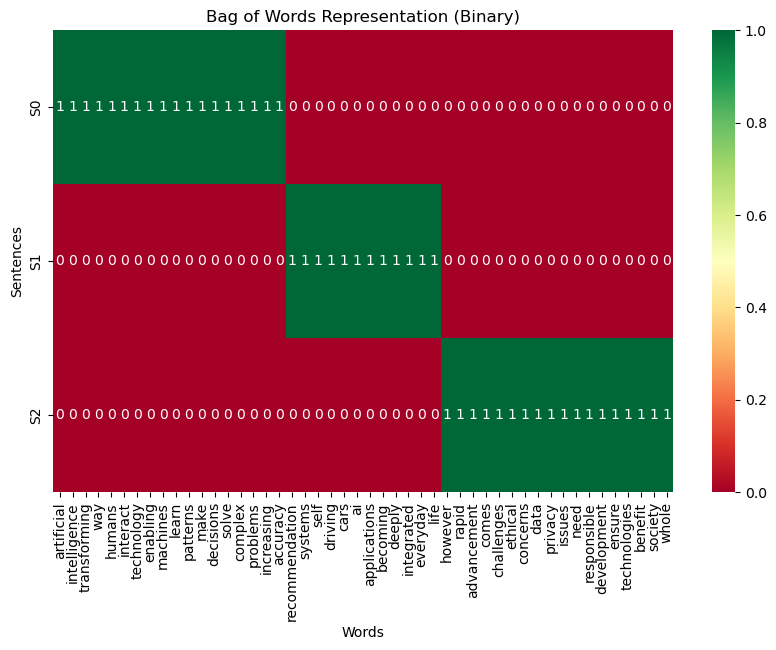

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import nltk
freq_words = word_freq_df['Word'].tolist()
X = []

for data in dataset:
    vector = []
    tokens = nltk.word_tokenize(data)
    for word in freq_words:
        if word in tokens:
            vector.append(1)
        else:
            vector.append(0)
    X.append(vector)

X = np.asarray(X)

plt.figure(figsize=(10, 6))
sns.heatmap(X, annot=True, cmap='RdYlGn',
            xticklabels=freq_words,
            yticklabels=[f"S{i}" for i in range(len(dataset))])

plt.title("Bag of Words Representation (Binary)")
plt.xlabel("Words")
plt.ylabel("Sentences")
plt.show()